In [3]:
import os
# Importing libraries
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create folders if they don't exist
os.makedirs('../data/cleaned', exist_ok=True)
os.makedirs('../visuals', exist_ok=True)

# ... Your existing data loading, cleaning, and feature engineering code ...

In [4]:
# movie_data_analysis.py

# Loading data sets
bom_df = pd.read_csv("../data/bom.movie_gross.csv")
rt_reviews_df = pd.read_csv("../data/rt.reviews.tsv", sep='\t', encoding='latin1')
rt_movie_info_df = pd.read_csv("../data/rt.movie_info.tsv", sep='\t', encoding='latin1')
tmdb_movies_df = pd.read_csv("../data/tmdb.movies.csv")
tn_movie_budgets_df = pd.read_csv("../data/tn.movie_budgets.csv")

# Previewing each
for name, df in [('Box office mojo', bom_df), ('Rotten tomatoes Reviews', rt_reviews_df), 
                 ('Rotten tomatoes movie info', rt_movie_info_df), ('The movie DB', tmdb_movies_df), 
                 ('The numbers', tn_movie_budgets_df)]:
    print(f"\n{name} Sample:")
    print(df.head())
    print(df.info())

## Data understanding of each dataframe

# Box office mojo dataset (movie_gross)
print(bom_df.shape)
bom_df.info()

## Observation
# Total rows: 3387 movies
# Columns: 5 - title, studio, domestic_gross, foreign_gross and year.
# The dataset is mostly complete with title and year having no missing values
# The column with more missing values is foreign_gross followed by domestic_gross and lastly studio.
# foreign_gross is stored as object instead of float, likely due to formatting issues.

# Reviewing Rotten Tomatoes dataset
rt_reviews_df.info()
print(rt_reviews_df.shape)
rt_reviews_df.isna().sum()

## Observation
# Total rows: 54,432 reviews
# Columns: 8 including id, review, rating, fresh, critic, top_critic, publisher, and date
# All rows have id, fresh, top_critic, and date
# missing values are significant in some columns
# - review: 5563 missing values
# - rating: 13517 missing
# - publisher: 309 missing values
# Date column can be converted to date-time format

# Reviewing Rotten Tomatoes dataset (movie_info)
rt_movie_info_df.info()
rt_movie_info_df.isna().sum()

## Observation
# Total rows: 1560 movie reviews
# Columns: 12 - id, synopsis, rating, genre, director, writer, theater_date, dvd_date, currency, box_office, runtime, studio
# Columns like id, rating, genre, and runtime are mostly complete.
# Missing values are significant in several columns
# - synopsis: 62 missing
# - director: 199 missing
# - writer: 449 missing
# - theater_date and dvd_date: both have 359 missing
# - box_office and currency: 1220 missing
# - studio: 1066 missing, most data missing
# Theater_date, dvd_date, and runtime should be converted to datetime or numeric for analysis.
# box_office and currency are object types need to be converted to numeric

# Reviewing the movie DB dataset (tmdb_movie df)
tmdb_movies_df.info()

## Observation
# Total movies: 26,517
# Columns: 10 - includes title info, ratings, language, and release_date
# No missing values across any of the 10 columns - very clean.
# unnamed column needs to be dropped
# release_date should be converted to datetime

# Reviewing The Numbers dataset (movie_budgets df)
tn_movie_budgets_df.info()

## Observation
# Total entries: 5,782 movies
# Columns: 6 - focused on financial and release information
# Complete data (no missing entries) across all columns
# Key financial metrics included:
# - production_budget
# - domestic_gross
# - worldwide_gross
# release_date is present, enabling time-based trend analysis

### IM DATABASE

# Loading the sqlite database
con = sqlite3.connect("../data/im.db")  # creating a connection

# Previewing the schema
pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type= "table";
""", con)

# Selecting movie_basics and movie_ratings tables
query = """
SELECT *
FROM movie_basics
"""
pd.read_sql(query, con).tail()

query = """
SELECT *
FROM movie_ratings
"""
pd.read_sql(query, con).tail()

# Joining the two tables using movie_id
query = """
SELECT *
FROM movie_basics
LEFT JOIN movie_ratings
USING(movie_id);
"""
movie_basics_rating_df = pd.read_sql(query, con)
movie_basics_rating_df.tail()

# Data cleaning

## Box office mojo dataset

# Creating a working copy
bom_clean_df = bom_df.copy()
bom_clean_df.info()

# Checking for duplicates
duplicated_rows = bom_clean_df.duplicated()
duplicated_rows.sum()

# Cleaning the bom_df (movie_gross) from Box office mojo dataset
bom_clean_df.columns

# Cleaning title column
# Checking for duplicates
key_columns = ['title', 'year']
dupl_row = bom_clean_df[bom_clean_df.duplicated(subset=key_columns, keep=False)]
dupl_row

# There are no duplicates
bom_clean_df.isna().sum()

# Cleaning studio column
bom_clean_df['studio'] = bom_clean_df['studio'].str.strip()

# Checking for missing values
missing_studio = bom_clean_df['studio'].isnull().sum()
missing_studio

# Filling in missing values
bom_clean_df['studio'] = bom_clean_df['studio'].fillna("unknown")

# Checking for missing values
bom_clean_df['studio'].isnull().sum()

missing_domestic_gross = bom_clean_df[bom_clean_df['domestic_gross'].isna()]
# Print the rows with missing domestic_gross
print("\nRows with missing domestic_gross:")
print(missing_domestic_gross[['title', 'studio', 'domestic_gross', 'foreign_gross', 'year']])

# Filling in missing values with mean
mean = bom_clean_df['domestic_gross'].mean()
bom_clean_df['domestic_gross'] = bom_clean_df['domestic_gross'].fillna(mean)

# Checking for null
bom_clean_df['domestic_gross'].isnull().sum()

# Cleaning year column
bom_clean_df["year"].dtype

# Cleaning foreign column
bom_clean_df['foreign_gross'].isnull().sum()

# Dropping foreign_gross column
bom_clean_df.drop(columns='foreign_gross', inplace=True)

## Cleaning Rotten Tomatoes reviews dataset

# Creating a copy
rt_reviews_clean_df = rt_reviews_df.copy()

# Missing values
rt_reviews_clean_df.isna().sum()

# Checking for id duplicates
duplicate_count = rt_reviews_clean_df.duplicated().sum()
print(f"Number of duplicates: {duplicate_count}")

# Checking for duplicates while focusing on specific columns for clarity
if all(col in rt_reviews_clean_df for col in ['id', 'review', 'critic', 'publisher', 'date']):
    initial_rows_rt_reviews = len(rt_reviews_clean_df)
    rt_reviews_clean_df.drop_duplicates(subset=['id', 'review', 'critic', 'publisher', 'date'])
    print(f"rt_reviews_clean_df: Removed {initial_rows_rt_reviews - len(rt_reviews_clean_df)} duplicates based on 'id', 'review', 'publisher', 'critic', and 'date'.")
else:
    print("rt_reviews_clean_df: Skipping duplicate check due to missing 'id', 'review', 'critic', or 'date' columns.")

# Checking for columns unique values in each column
for column in rt_reviews_clean_df.columns:
    print(f"\n{column} unique values:")
    print(rt_reviews_df[column].unique())

# Filling in review column
if 'review' in rt_reviews_clean_df.columns:
    missing_review_count = rt_reviews_clean_df['review'].isna().sum()
    if missing_review_count > 0:
        rt_reviews_clean_df['review'] = rt_reviews_clean_df['review'].fillna('No Review Text')
        print(f"Filled {missing_review_count} missing 'review' values with 'No Review Text'.")

# Dropping unuseful columns
rt_reviews_clean_df.drop(columns=['rating'], inplace=True)

# Checking if the columns are dropped
rt_reviews_clean_df.columns

# Filling critic column missing values with unknown
rt_reviews_clean_df['critic'] = rt_reviews_clean_df['critic'].fillna("Unknown")

# Filling publisher missing with unknown
rt_reviews_clean_df['publisher'] = rt_reviews_clean_df['publisher'].fillna("Unknown")

# Converting date into datetime format
rt_reviews_clean_df['date'] = pd.to_datetime(rt_reviews_clean_df['date'])

# Checking effectiveness
rt_reviews_clean_df["date"].dtype

# Checking missing values in the df
rt_reviews_clean_df.isna().sum()

## Cleaning Rotten Tomatoes movie info dataset

# Creating a working copy
rt_movie_info_clean = rt_movie_info_df.copy()

# Checking for missing values
rt_movie_info_clean.isnull().sum()

# Checking for columns unique values in each column
for column in rt_movie_info_clean.columns:
    print(f"\n{column} unique values:")
    print(rt_movie_info_clean[column].unique())

## Handling missing values column by column

### Filling in categorical columns with 'unknown'

for col in ['synopsis', 'rating', 'genre', 'director', 'writer', 'studio']:
    if col in rt_movie_info_clean.columns:
        initial_missing_count = rt_movie_info_clean[col].isnull().sum()
        if initial_missing_count > 0:
            rt_movie_info_clean[col] = rt_movie_info_clean[col].fillna('Unknown')
            print(f"Filled {initial_missing_count} missing '{col}' values with 'Unknown'.")

rt_movie_info_clean.isna().sum()

# Converting theatre date and dvd date into datetime format
rt_movie_info_clean['theater_date'] = pd.to_datetime(rt_movie_info_clean['theater_date'], errors='coerce')
rt_movie_info_clean['dvd_date'] = pd.to_datetime(rt_movie_info_clean['dvd_date'], errors='coerce')

# Filling in missing runtime values with median runtime
rt_movie_info_clean["runtime"] = rt_movie_info_clean["runtime"].astype(str).str.replace('minutes', '', regex=False)
rt_movie_info_clean["runtime"] = pd.to_numeric(rt_movie_info_clean["runtime"], errors='coerce')
# Filling missing values with median values
runtime_median = rt_movie_info_clean["runtime"].median()
rt_movie_info_clean["runtime"] = rt_movie_info_clean["runtime"].fillna(runtime_median)

rt_movie_info_clean.isna().sum()

# Dropping missing theater date and dvd date missing values
rt_movie_info_clean = rt_movie_info_clean.drop(columns=['currency', 'box_office'])

## Cleaning tmdb_movies_df (The movie DB dataset)
tmdb_movies_df.info()

# Dropping unnamed column
tmdb_movies_df.drop(columns=["Unnamed: 0", 'genre_ids'], inplace=True)

# Checking for unique values in each column
for column in tmdb_movies_df.columns:
    print(f"\n{column} unique values:")
    print(tmdb_movies_df[column].unique())

# Standardizing categorical columns for consistency (lowercase and strip)
tmdb_movies_df['original_language'] = tmdb_movies_df['original_language'].str.strip().str.lower()
tmdb_movies_df['original_title'] = tmdb_movies_df['original_title'].str.strip()
tmdb_movies_df['title'] = tmdb_movies_df['title'].str.strip()

# Converting release date to datetime format
tmdb_movies_df["release_date"] = pd.to_datetime(tmdb_movies_df["release_date"], errors='coerce')

# Extract year and month from movie_budgets tmdb df
tmdb_movies_df['release_year'] = tmdb_movies_df['release_date'].dt.year
tmdb_movies_df['release_month'] = tmdb_movies_df['release_date'].dt.month

tmdb_movies_df.columns

## Cleaning movie_budgets df (The Numbers Dataset)
tn_movie_budgets_df.info()

# Checking for unique values in each column
for column in tn_movie_budgets_df.columns:
    print(f"\n{column} unique values:")
    print(tn_movie_budgets_df[column].unique())

# Converting currency strings to numeric
print("\ntn_movie_budgets_df...")
for col in ['production_budget', 'domestic_gross', 'worldwide_gross']:
    if col in tn_movie_budgets_df.columns and tn_movie_budgets_df[col].dtype == 'object':
        tn_movie_budgets_df[col] = tn_movie_budgets_df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
        tn_movie_budgets_df[col] = pd.to_numeric(tn_movie_budgets_df[col], errors='coerce')

# Checking
tn_movie_budgets_df.head(10)

# Converting release date to datetime format
tn_movie_budgets_df['release_date'] = pd.to_datetime(tn_movie_budgets_df['release_date'])

# Extract release year and month from tn budget
tn_movie_budgets_df['release_year'] = tn_movie_budgets_df['release_date'].dt.year
tn_movie_budgets_df['release_month'] = tn_movie_budgets_df['release_date'].dt.month

tn_movie_budgets_df.columns

## Feature engineering

### Calculating review counts from rt_reviews_clean_df

# Computing review counts and freshness score
review_counts = rt_reviews_clean_df.groupby('id').agg(
    Review_counts=('fresh', 'count'),
    Freshness_score=('fresh', lambda x: (x == 'fresh').sum() / len(x))).reset_index()
review_counts

### Merging review_counts and rt_movie_info_clean df
rt_combined_df = pd.merge(rt_movie_info_clean, review_counts, on='id', how='left')
rt_combined_df

### Merging tmdb_movies_df and tn_movie_budgets_df
# Renaming tmdb title column to tmdb_title for differentiation
tmdb_movies_df.rename(columns={'title': 'tmdb_title'}, inplace=True)

# Renaming movie column in tn_movie_budgets_df for easy understanding when merging with tmdb
tn_movie_budgets_df.rename(columns={'movie': 'title'}, inplace=True)

# Merging tn_movie_budgets_df and tmdb_movies_df on title and release year
tmdb_tn_merged = pd.merge(tn_movie_budgets_df, tmdb_movies_df, left_on=['title', 'release_year'], right_on=['tmdb_title', 'release_year'], how='left')
tmdb_tn_merged

# Rename id_x for merging and preserve release_date_x as release_date
tmdb_tn_merged.rename(columns={'id_x': 'id', 'release_date_x': 'release_date'}, inplace=True)
# Drop suffix columns and low-value metadata, excluding release_date
redundant_cols = [col for col in tmdb_tn_merged.columns if col.endswith('_y')]
low_value_cols = [
    'id_y', 'tmdb_title', 'original_title', 'original_language',
    'release_date_y', 'popularity', 'vote_count', 'vote_average', 'Unnamed: 0', 'genre_ids'
]
drop_columns = list(set(redundant_cols + low_value_cols))
tmdb_tn_merged.drop(columns=drop_columns, errors='ignore', inplace=True)
tmdb_tn_merged.tail()

### Final feature engineering
tmdb_tn_merged['Profit'] = tmdb_tn_merged['worldwide_gross'] - tmdb_tn_merged['production_budget']
tmdb_tn_merged['ROI'] = tmdb_tn_merged['Profit'] / tmdb_tn_merged['production_budget']
tmdb_tn_merged['Domestic_vs_Worldwide_Ratio'] = tmdb_tn_merged['domestic_gross'] / tmdb_tn_merged['worldwide_gross']
tmdb_tn_merged['Release_Month'] = tmdb_tn_merged['release_date'].dt.month
tmdb_tn_merged['Day_of_Week'] = tmdb_tn_merged['release_date'].dt.day_name()

### Director and Writer Metrics
review_metrics = rt_reviews_clean_df.groupby('id').agg(
    review_count=('fresh', 'count'),
    freshness_score=('fresh', lambda x: (x == 'fresh').sum() / len(x))
).reset_index()

# Merge review metrics with director and writer
review_metrics_full = pd.merge(rt_combined_df[['id', 'director', 'writer']], review_metrics, on='id', how='left')
review_metrics_full

# Group by director
director_metrics = review_metrics_full.groupby('director').agg(
    director_avg_freshness=('freshness_score', 'mean'),
    director_avg_reviews=('review_count', 'mean'),
    director_movie_count=('id', 'count')
).reset_index()

# Group by writer
writer_metrics = review_metrics_full.groupby('writer').agg(
    writer_avg_freshness=('freshness_score', 'mean'),
    writer_avg_reviews=('review_count', 'mean'),
    writer_movie_count=('id', 'count')
).reset_index()

director_metrics

writer_metrics

# Top directors avg reviews
top_directors_by_reviews = director_metrics.sort_values(by='director_avg_reviews', ascending=False).head(10)
top_directors_by_reviews

# Top writers avg reviews
top_writers_by_reviews = writer_metrics.sort_values(by='writer_avg_reviews', ascending=False).head(10)
top_writers_by_reviews

# DATA VALIDATION

### The Box Office Movies / The Movie DB and The Numbers merged dataset

# Checking Data Types
tmdb_tn_merged.dtypes

# 1. Re-run Summary Statistics ---
print("--- 1. Re-run Initial Data Profiling/Summary Statistics ---")
print("\n1.1. `df.info()` - Check Data Types and Non-Null Counts:")
tmdb_tn_merged.info()

print("\n1.2. `df.describe()` - Summary Statistics for Numerical Columns:")
print(tmdb_tn_merged.describe())

print("\n1.3. `df.nunique()` - Number of Unique Values per Column:")
print(tmdb_tn_merged.nunique())

print("\n1.4. `df.isnull().sum()` - Check for Remaining Missing Values:")
print(tmdb_tn_merged.isnull().sum())
print("\n" + "="*50 + "\n")

# 2. Verify Specific Cleaning Operations ---
print("--- 2. Verify Specific Cleaning Operations ---")

print("\n2.1. Duplicates Check:")
if tmdb_tn_merged.duplicated(subset=['id', 'title', 'production_budget', 'domestic_gross', 'worldwide_gross']).sum() == 0:
    print("  -> No exact duplicate rows (based on specified subset) found.")
else:
    print("  -> WARNING: Duplicates still exist (based on specified subset)! Investigate.")
    print(tmdb_tn_merged[tmdb_tn_merged.duplicated(subset=['id', 'title', 'production_budget', 'domestic_gross', 'worldwide_gross'], keep=False)])

print("\n2.2. Categorical Data Consistency (`.value_counts()`):")
print("  'title' Value Counts:")
print(tmdb_tn_merged['title'].value_counts())
if tmdb_tn_merged['title'].isin(['title']).all():
    print("  -> 'title' column categories are consistent with expected values.")
else:
    print("  -> WARNING: 'title' column has unexpected titles!")

print("\n2.3. Uniqueness Checks:")
if not tmdb_tn_merged['id'].is_unique:
    print(f"  -> WARNING: 'ID' is NOT unique! Duplicates found:")
    print(tmdb_tn_merged[tmdb_tn_merged['id'].duplicated(keep=False)].sort_values('id'))
else:
    print("  -> 'id' column is unique.")

# The duplicates in the id column were kept as the movie titles, production budget, domestic and worldwide gross were all different.

### Outlier Detection and Cleaning

# Combined outlier removal for tmdb_tn_merged
# Domestic Gross
Q1_dom = tmdb_tn_merged['domestic_gross'].quantile(0.25)
Q3_dom = tmdb_tn_merged['domestic_gross'].quantile(0.75)
IQR_dom = Q3_dom - Q1_dom
lower_bound_dom = Q1_dom - 1.5 * IQR_dom
upper_bound_dom = Q3_dom + 1.5 * IQR_dom
outliers_dom = tmdb_tn_merged[(tmdb_tn_merged['domestic_gross'] < lower_bound_dom) | (tmdb_tn_merged['domestic_gross'] > upper_bound_dom)]

print("--- Outliers using the IQR method (Domestic Gross) ---")
print(f"Q1 (25th percentile): {Q1_dom}")
print(f"Q3 (75th percentile): {Q3_dom}")
print(f"IQR: {IQR_dom}")
print(f"Lower Bound: {lower_bound_dom}")
print(f"Upper Bound: {upper_bound_dom}")
if not outliers_dom.empty:
    print("\nOutliers found:")
    print(outliers_dom)
else:
    print("\nNo outliers found.")

# Production Budget
Q1_prod = tmdb_tn_merged['production_budget'].quantile(0.25)
Q3_prod = tmdb_tn_merged['production_budget'].quantile(0.75)
IQR_prod = Q3_prod - Q1_prod
lower_bound_prod = Q1_prod - 1.5 * IQR_prod
upper_bound_prod = Q3_prod + 1.5 * IQR_prod
outliers_prod = tmdb_tn_merged[(tmdb_tn_merged['production_budget'] < lower_bound_prod) | (tmdb_tn_merged['production_budget'] > upper_bound_prod)]

print("--- Outliers using the IQR method (Production Budget) ---")
print(f"Q1 (25th percentile): {Q1_prod}")
print(f"Q3 (75th percentile): {Q3_prod}")
print(f"IQR: {IQR_prod}")
print(f"Lower Bound: {lower_bound_prod}")
print(f"Upper Bound: {upper_bound_prod}")
if not outliers_prod.empty:
    print("\nOutliers found:")
    print(outliers_prod)
else:
    print("\nNo outliers found.")

# Worldwide Gross
Q1_ww = tmdb_tn_merged['worldwide_gross'].quantile(0.25)
Q3_ww = tmdb_tn_merged['worldwide_gross'].quantile(0.75)
IQR_ww = Q3_ww - Q1_ww
lower_bound_ww = Q1_ww - 1.5 * IQR_ww
upper_bound_ww = Q3_ww + 1.5 * IQR_ww
outliers_ww = tmdb_tn_merged[(tmdb_tn_merged['worldwide_gross'] < lower_bound_ww) | (tmdb_tn_merged['worldwide_gross'] > upper_bound_ww)]

print("--- Outliers using the IQR method (Worldwide Gross) ---")
print(f"Q1 (25th percentile): {Q1_ww}")
print(f"Q3 (75th percentile): {Q3_ww}")
print(f"IQR: {IQR_ww}")
print(f"Lower Bound: {lower_bound_ww}")
print(f"Upper Bound: {upper_bound_ww}")
if not outliers_ww.empty:
    print("\nOutliers found:")
    print(outliers_ww)
else:
    print("\nNo outliers found.")

# Release Year
Q1_year = tmdb_tn_merged['release_year'].quantile(0.25)
Q3_year = tmdb_tn_merged['release_year'].quantile(0.75)
IQR_year = Q3_year - Q1_year
lower_bound_year = Q1_year - 1.5 * IQR_year
upper_bound_year = Q3_year + 1.5 * IQR_year
outliers_year = tmdb_tn_merged[(tmdb_tn_merged['release_year'] < lower_bound_year) | (tmdb_tn_merged['release_year'] > upper_bound_year)]

print("--- Outliers using the IQR method (Release Year) ---")
print(f"Q1 (25th percentile): {Q1_year}")
print(f"Q3 (75th percentile): {Q3_year}")
print(f"IQR: {IQR_year}")
print(f"Lower Bound: {lower_bound_year}")
print(f"Upper Bound: {upper_bound_year}")
if not outliers_year.empty:
    print("\nOutliers found:")
    print(outliers_year)
else:
    print("\nNo outliers found.")

# Combine all outlier conditions
tmdb_tn_merged_cleaned = tmdb_tn_merged[
    (tmdb_tn_merged['domestic_gross'] >= lower_bound_dom) & (tmdb_tn_merged['domestic_gross'] <= upper_bound_dom) &
    (tmdb_tn_merged['production_budget'] >= lower_bound_prod) & (tmdb_tn_merged['production_budget'] <= upper_bound_prod) &
    (tmdb_tn_merged['worldwide_gross'] >= lower_bound_ww) & (tmdb_tn_merged['worldwide_gross'] <= upper_bound_ww) &
    (tmdb_tn_merged['release_year'] >= lower_bound_year) & (tmdb_tn_merged['release_year'] <= upper_bound_year)
]
print("Original DataFrame shape:", tmdb_tn_merged.shape)
print("Cleaned DataFrame shape (All Columns):", tmdb_tn_merged_cleaned.shape)

### Rotten Tomatoes Movie information and Reviews
rt_combined_df.describe()

print("--- 1. Re-run Initial Data Profiling/Summary Statistics ---")
print("\n1.1. `df.info()` - Check Data Types and Non-Null Counts:")
rt_combined_df.info()

print("\n1.2. `df.describe()` - Summary Statistics for Numerical Columns:")
print(rt_combined_df.describe())

print("\n1.3. `df.nunique()` - Number of Unique Values per Column:")
print(rt_combined_df.nunique())

print("\n1.4. `df.isnull().sum()` - Check for Remaining Missing Values:")
print(rt_combined_df.isnull().sum())
print("\n" + "="*50 + "\n")

#### Freshness Score
rt_combined_df.columns
fresh_median = rt_combined_df['Freshness_score'].median()
rt_combined_df_cleaned = rt_combined_df.copy()
rt_combined_df_cleaned.loc[:, 'Freshness_score'] = rt_combined_df_cleaned.loc[:, 'Freshness_score'].fillna(fresh_median)

Q1 = rt_combined_df_cleaned['Freshness_score'].quantile(0.25)
Q3 = rt_combined_df_cleaned['Freshness_score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = rt_combined_df_cleaned[(rt_combined_df_cleaned['Freshness_score'] < lower_bound) | (rt_combined_df_cleaned['Freshness_score'] > upper_bound)]

print("--- Outliers using the IQR method (Freshness Score) ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

#### Review Counts
rt_combined_df_cleaned.isnull().sum()
rt_combined_df_cleaned = rt_combined_df_cleaned.drop(columns=['theater_date', 'dvd_date'], axis=1)
rt_combined_df_cleaned.loc[:, 'Review_counts'] = rt_combined_df_cleaned.loc[:, 'Review_counts'].fillna(0)

rt_combined_df_cleaned.isnull().sum()

Q1 = rt_combined_df_cleaned['Review_counts'].quantile(0.25)
Q3 = rt_combined_df_cleaned['Review_counts'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = rt_combined_df_cleaned[(rt_combined_df_cleaned['Review_counts'] < lower_bound) | (rt_combined_df_cleaned['Review_counts'] > upper_bound)]

print("--- Outliers using the IQR method (Review Counts) ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

rt_combined_df_cleaned = rt_combined_df_cleaned[(rt_combined_df_cleaned['Review_counts'] >= lower_bound) & (rt_combined_df_cleaned['Review_counts'] <= upper_bound)]
print("Original DataFrame shape:", rt_combined_df.shape)
print("Cleaned DataFrame shape (Review Counts):", rt_combined_df_cleaned.shape)

#### Runtime
Q1 = rt_combined_df_cleaned['runtime'].quantile(0.25)
Q3 = rt_combined_df_cleaned['runtime'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = rt_combined_df_cleaned[(rt_combined_df_cleaned['runtime'] < lower_bound) | (rt_combined_df_cleaned['runtime'] > upper_bound)]

print("--- Outliers using the IQR method (Runtime) ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

rt_combined_df_cleaned = rt_combined_df_cleaned[(rt_combined_df_cleaned['runtime'] >= lower_bound) & (rt_combined_df_cleaned['runtime'] <= upper_bound)]
print("Original DataFrame shape:", rt_combined_df.shape)
print("Cleaned DataFrame shape (Runtime):", rt_combined_df_cleaned.shape)

## Directors And Writer Metrics

### Writers
print("--- 1. Re-run Initial Data Profiling/Summary Statistics ---")
print("\n1.1. `df.info()` - Check Data Types and Non-Null Counts:")
top_writers_by_reviews.info()

print("\n1.2. `df.describe()` - Summary Statistics for Numerical Columns:")
print(top_writers_by_reviews.describe())

print("\n1.3. `df.nunique()` - Number of Unique Values per Column:")
print(top_writers_by_reviews.nunique())

print("\n1.4. `df.isnull().sum()` - Check for Remaining Missing Values:")
print(top_writers_by_reviews.isnull().sum())
print("\n" + "="*50 + "\n")

#### writer_avg_freshness
Q1 = top_writers_by_reviews['writer_avg_freshness'].quantile(0.25)
Q3 = top_writers_by_reviews['writer_avg_freshness'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = top_writers_by_reviews[(top_writers_by_reviews['writer_avg_freshness'] < lower_bound) | (top_writers_by_reviews['writer_avg_freshness'] > upper_bound)]

print("--- Outliers using the IQR method (Writer Avg Freshness) ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

top_writers_by_reviews_cleaned = top_writers_by_reviews[(top_writers_by_reviews['writer_avg_freshness'] >= lower_bound) & (top_writers_by_reviews['writer_avg_freshness'] <= upper_bound)]
print("Original DataFrame shape:", top_writers_by_reviews.shape)
print("Cleaned DataFrame shape (Writer Avg Freshness):", top_writers_by_reviews_cleaned.shape)

#### writer_movie_count
Q1 = top_writers_by_reviews['writer_movie_count'].quantile(0.25)
Q3 = top_writers_by_reviews['writer_movie_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = top_writers_by_reviews[(top_writers_by_reviews['writer_movie_count'] < lower_bound) | (top_writers_by_reviews['writer_movie_count'] > upper_bound)]

print("--- Outliers using the IQR method (Writer Movie Count) ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

#### writer_avg_reviews
Q1 = top_writers_by_reviews['writer_avg_reviews'].quantile(0.25)
Q3 = top_writers_by_reviews['writer_avg_reviews'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = top_writers_by_reviews[(top_writers_by_reviews['writer_avg_reviews'] < lower_bound) | (top_writers_by_reviews['writer_avg_reviews'] > upper_bound)]

print("--- Outliers using the IQR method (Writer Avg Reviews) ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

top_writers_by_reviews_cleaned = top_writers_by_reviews[(top_writers_by_reviews['writer_avg_reviews'] >= lower_bound) & (top_writers_by_reviews['writer_avg_reviews'] <= upper_bound)]
print("Original DataFrame shape:", top_writers_by_reviews.shape)
print("Cleaned DataFrame shape (Writer Avg Reviews):", top_writers_by_reviews_cleaned.shape)

### Directors
top_directors_by_reviews.isnull().sum()

print("--- 1. Re-run Initial Data Profiling/Summary Statistics ---")
print("\n1.1. `df.info()` - Check Data Types and Non-Null Counts:")
top_directors_by_reviews.info()

print("\n1.2. `df.describe()` - Summary Statistics for Numerical Columns:")
print(top_directors_by_reviews.describe())

print("\n1.3. `df.nunique()` - Number of Unique Values per Column:")
print(top_directors_by_reviews.nunique())

print("\n1.4. `df.isnull().sum()` - Check for Remaining Missing Values:")
print(top_directors_by_reviews.isnull().sum())
print("\n" + "="*50 + "\n")

#### director_avg_freshness
Q1 = top_directors_by_reviews['director_avg_freshness'].quantile(0.25)
Q3 = top_directors_by_reviews['director_avg_freshness'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = top_directors_by_reviews[(top_directors_by_reviews['director_avg_freshness'] < lower_bound) | (top_directors_by_reviews['director_avg_freshness'] > upper_bound)]

print("--- Outliers using the IQR method (Director Avg Freshness) ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

top_directors_by_reviews_cleaned = top_directors_by_reviews[(top_directors_by_reviews['director_avg_freshness'] >= lower_bound) & (top_directors_by_reviews['director_avg_freshness'] <= upper_bound)]
print("Original DataFrame shape:", top_directors_by_reviews.shape)
print("Cleaned DataFrame shape (Director Avg Freshness):", top_directors_by_reviews_cleaned.shape)

#### director_avg_reviews
Q1 = top_directors_by_reviews['director_avg_reviews'].quantile(0.25)
Q3 = top_directors_by_reviews['director_avg_reviews'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = top_directors_by_reviews[(top_directors_by_reviews['director_avg_reviews'] < lower_bound) | (top_directors_by_reviews['director_avg_reviews'] > upper_bound)]

print("--- Outliers using the IQR method (Director Avg Reviews) ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

top_directors_by_reviews_cleaned = top_directors_by_reviews[(top_directors_by_reviews['director_avg_reviews'] >= lower_bound) & (top_directors_by_reviews['director_avg_reviews'] <= upper_bound)]
print("Original DataFrame shape:", top_directors_by_reviews.shape)
print("Cleaned DataFrame shape (Director Avg Reviews):", top_directors_by_reviews_cleaned.shape)

#### director_movie_count
Q1 = top_directors_by_reviews['director_movie_count'].quantile(0.25)
Q3 = top_directors_by_reviews['director_movie_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = top_directors_by_reviews[(top_directors_by_reviews['director_movie_count'] < lower_bound) | (top_directors_by_reviews['director_movie_count'] > upper_bound)]

print("--- Outliers using the IQR method (Director Movie Count) ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")



Box office mojo Sample:
                                         title studio  domestic_gross  \
0                                  Toy Story 3     BV     415000000.0   
1                   Alice in Wonderland (2010)     BV     334200000.0   
2  Harry Potter and the Deathly Hallows Part 1     WB     296000000.0   
3                                    Inception     WB     292600000.0   
4                          Shrek Forever After   P/DW     238700000.0   

  foreign_gross  year  
0     652000000  2010  
1     691300000  2010  
2     664300000  2010  
3     535700000  2010  
4     513900000  2010  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year       

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB

Rows with missing domestic_gross:
                                      title   studio  domestic_gross  \
230              It's a Wonderful Afterlife      UTV             NaN   
298   Celine: Through the Eyes of the World     Sony             NaN   
302                              White Lion    Scre.             NaN   
306                        Badmaash Company     Yash             NaN   
327                      Aashayein (Wishes)  Relbig.             NaN   
537                                   Force     

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26517 entries, 0 to 26516
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         26517 non-null  int64  
 1   genre_ids          26517 non-null  object 
 2   id                 26517 non-null  int64  
 3   original_language  26517 non-null  object 
 4   original_title     26517 non-null  object 
 5   popularity         26517 non-null  float64
 6   release_date       26517 non-null  object 
 7   title              26517 non-null  object 
 8   vote_average       26517 non-null  float64
 9   vote_count         26517 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 2.0+ MB

id unique values:
[ 12444  10191  10138 ... 381231 366854 309885]

original_language unique values:
['en' 'nl' 'es' 'ja' 'sv' 'de' 'fr' 'cn' 'it' 'ru' 'zh' 'hi' 'no' 'ko'
 'da' 'fi' 'pl' 'te' 'hu' 'tr' 'pt' 'he' 'fa' 'th' 'cs' 'et' 'tl' 'lt'
 'xx' 'bs'

--- 1. Re-run Initial Data Profiling/Summary Statistics ---

1.1. `df.info()` - Check Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 5940 entries, 0 to 5939
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id                           5940 non-null   int64         
 1   release_date                 5940 non-null   datetime64[ns]
 2   title                        5940 non-null   object        
 3   production_budget            5940 non-null   int64         
 4   domestic_gross               5940 non-null   int64         
 5   worldwide_gross              5940 non-null   int64         
 6   release_year                 5940 non-null   int64         
 7   release_month_x              5940 non-null   int64         
 8   Profit                       5940 non-null   int64         
 9   ROI                          5940 non-null   float64   

--- Outliers using the IQR method (Writer Movie Count) ---
Q1 (25th percentile): 1.0
Q3 (75th percentile): 1.0
IQR: 0.0
Lower Bound: 1.0
Upper Bound: 1.0

No outliers found.
--- Outliers using the IQR method (Writer Avg Reviews) ---
Q1 (25th percentile): 252.75
Q3 (75th percentile): 261.5
IQR: 8.75
Lower Bound: 239.625
Upper Bound: 274.625

Outliers found:
              writer  writer_avg_freshness  writer_avg_reviews  \
632  Martin McDonagh              0.911243               338.0   
423      James Ivory              0.949091               275.0   

     writer_movie_count  
632                   1  
423                   1  
Original DataFrame shape: (10, 4)
Cleaned DataFrame shape (Writer Avg Reviews): (8, 4)
--- 1. Re-run Initial Data Profiling/Summary Statistics ---

1.1. `df.info()` - Check Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 10 entries, 659 to 935
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
-

In [5]:
# Save cleaned DataFrames to data/cleaned folder
tmdb_tn_merged_cleaned.to_csv('../data/cleaned/tmdb_tn_merged_cleaned.csv', index=False)
rt_combined_df_cleaned.to_csv('../data/cleaned/rt_combined_df_cleaned.csv', index=False)
top_directors_by_reviews_cleaned.to_csv('../data/cleaned/top_directors_by_reviews_cleaned.csv', index=False)
top_writers_by_reviews_cleaned.to_csv('../data/cleaned/top_writers_by_reviews_cleaned.csv', index=False)

print("Cleaned datasets saved to 'data/cleaned' folder.")

Cleaned datasets saved to 'data/cleaned' folder.


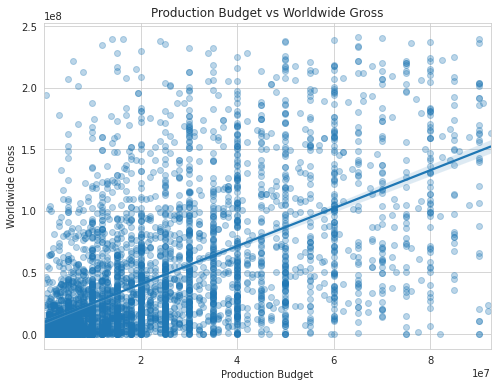

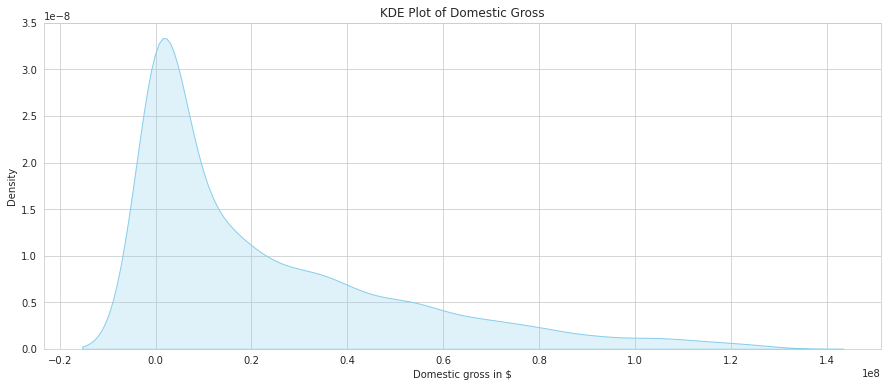

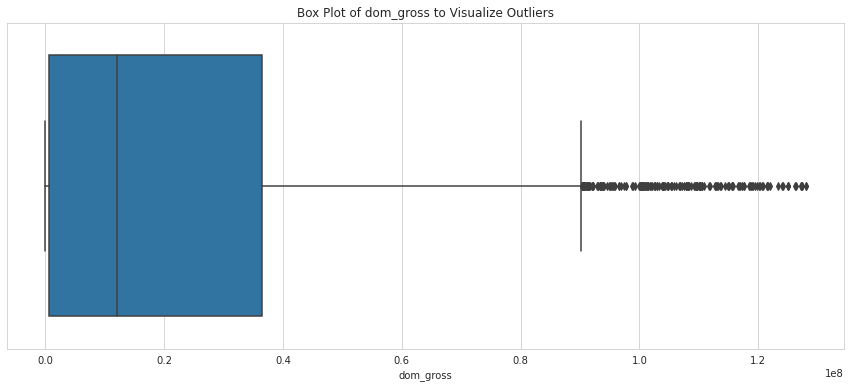

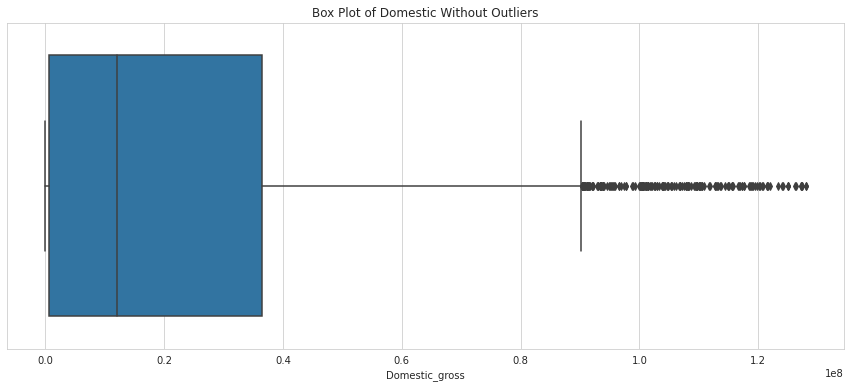

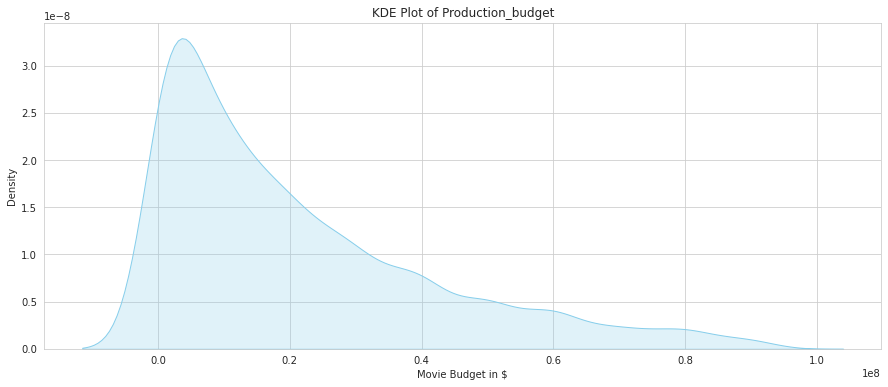

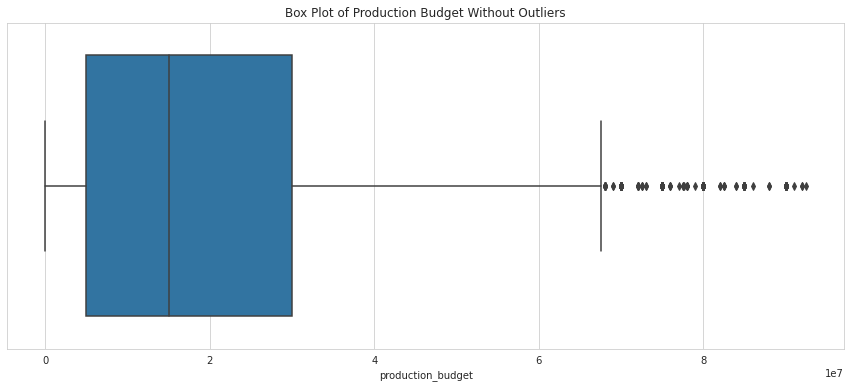

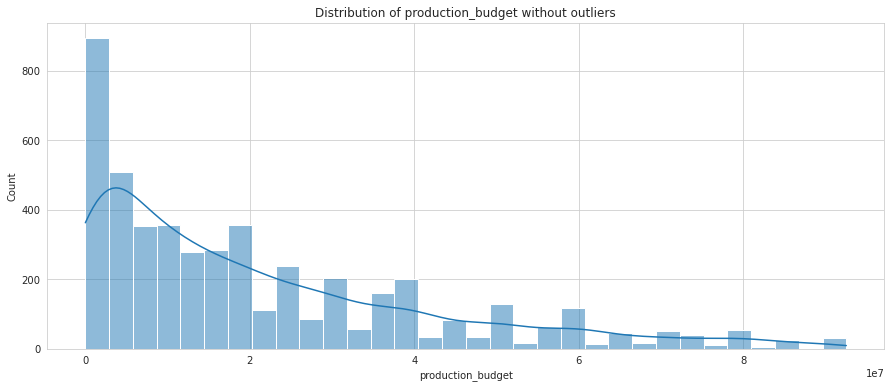

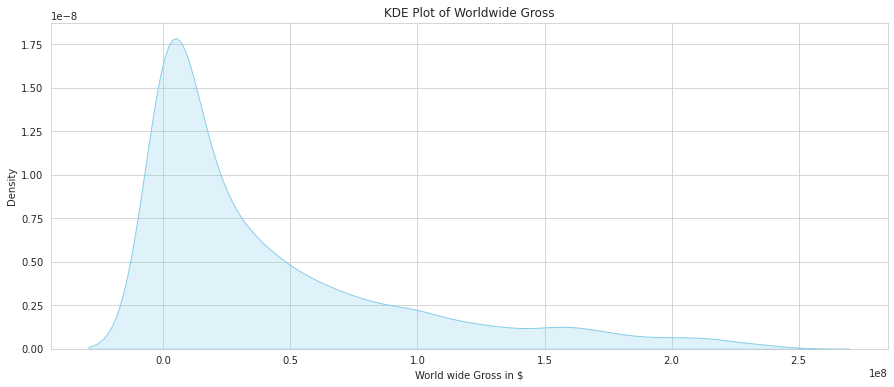

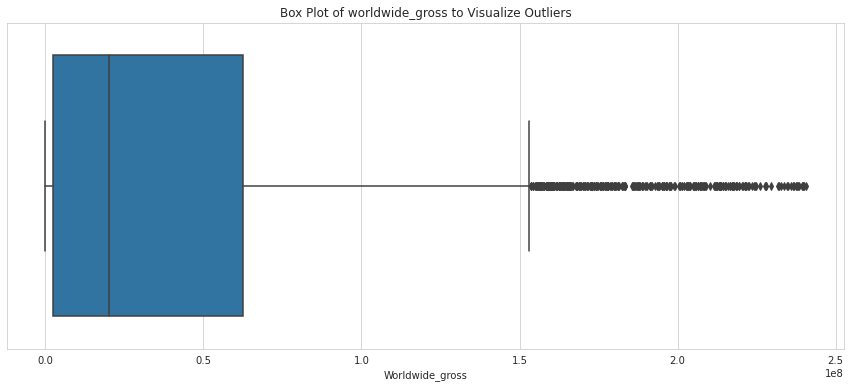

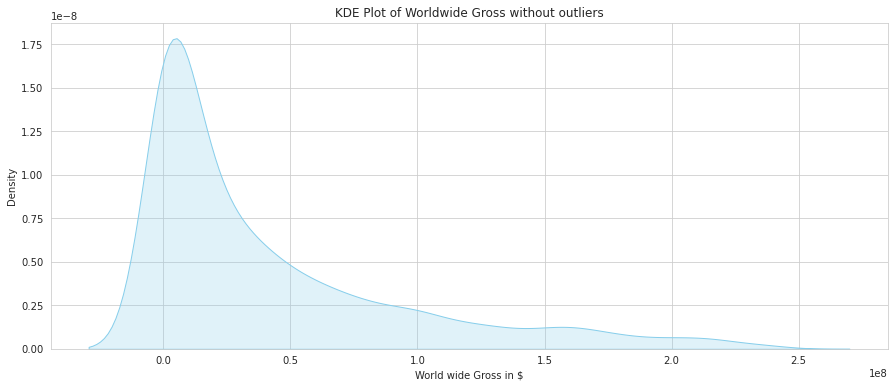

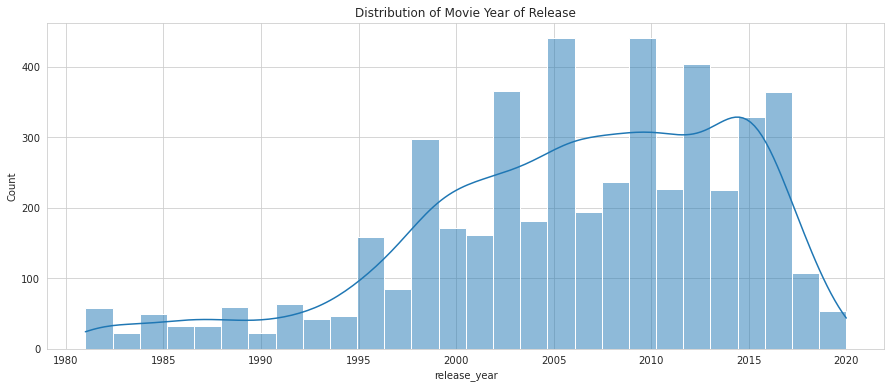

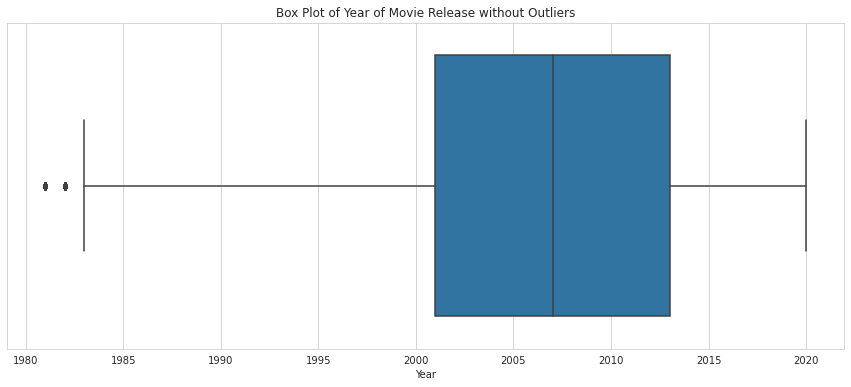

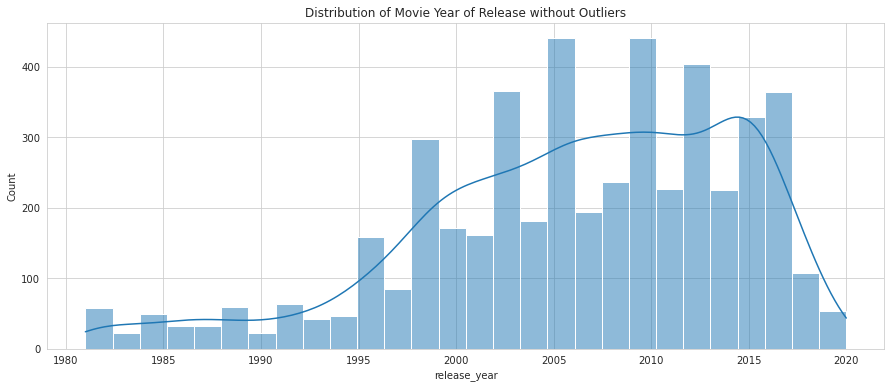

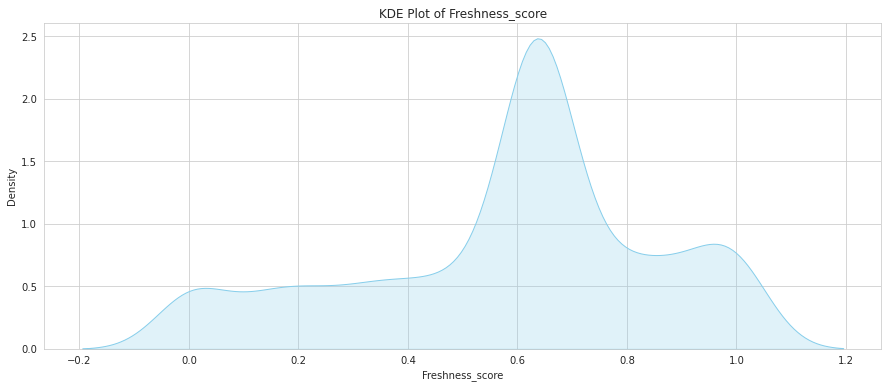

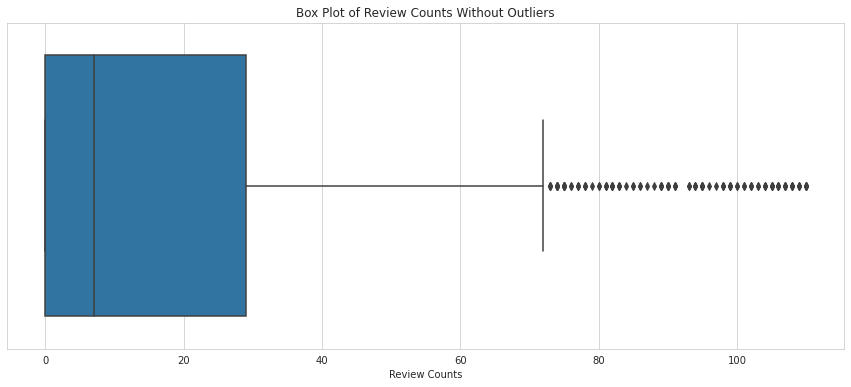

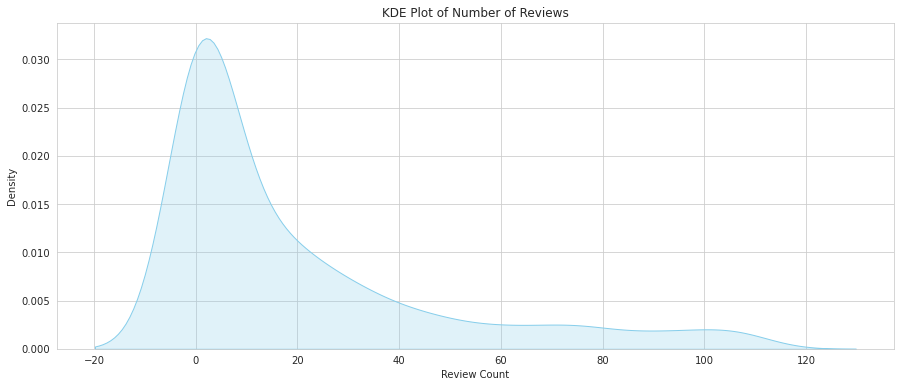

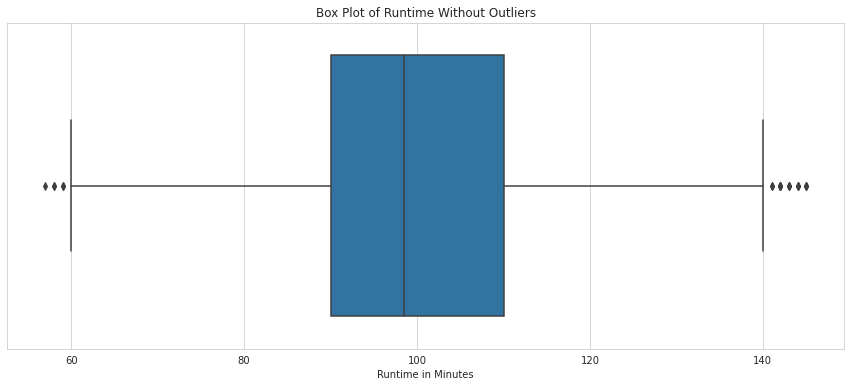

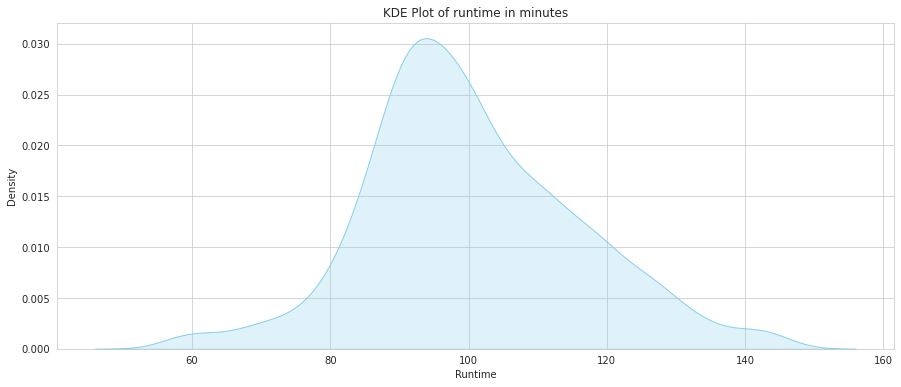

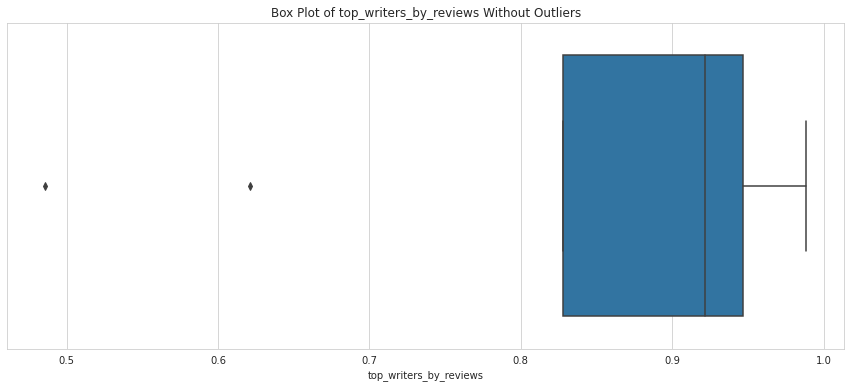

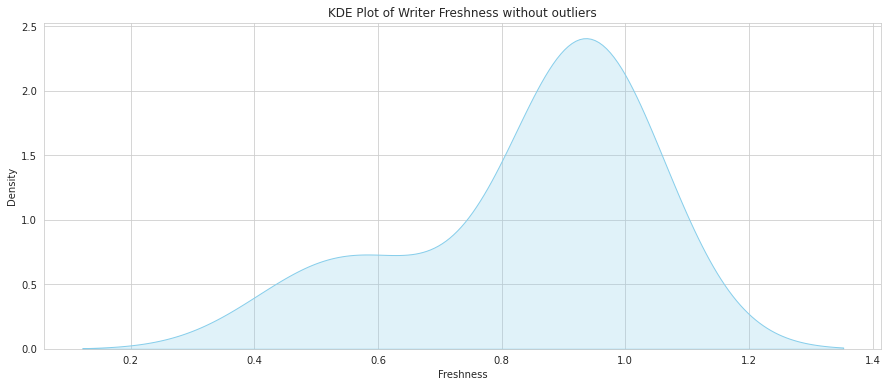

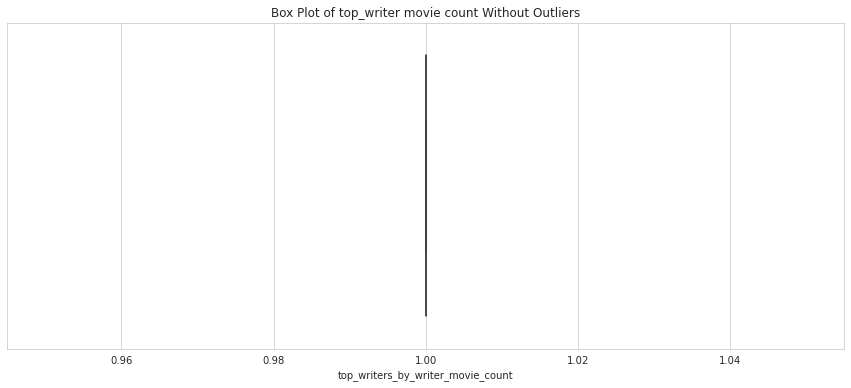

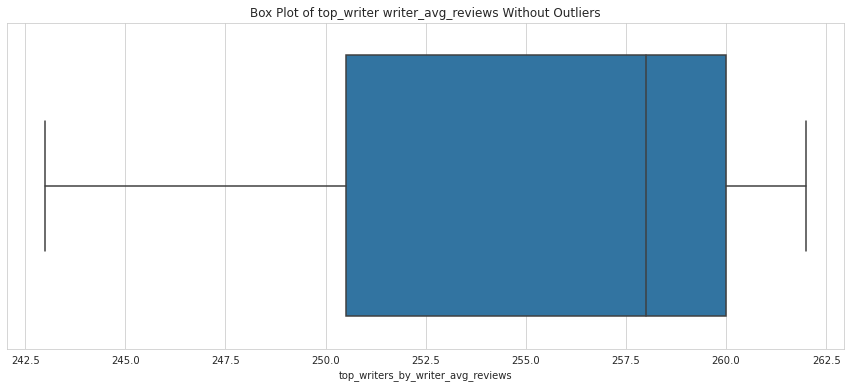

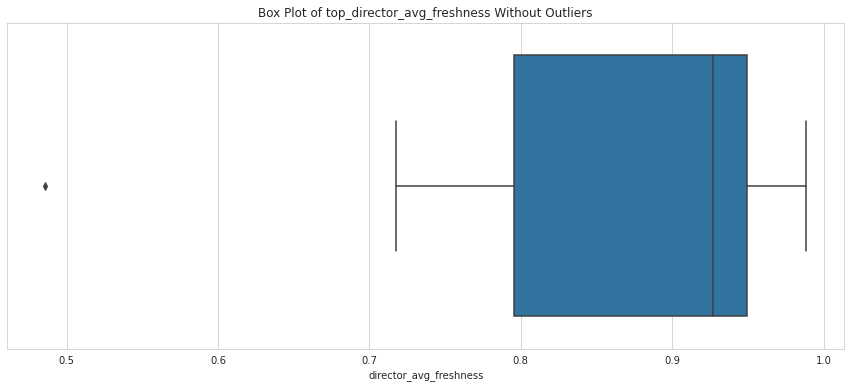

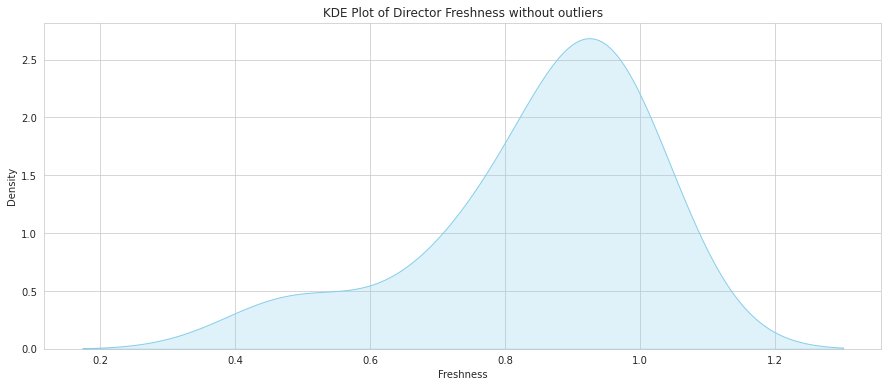

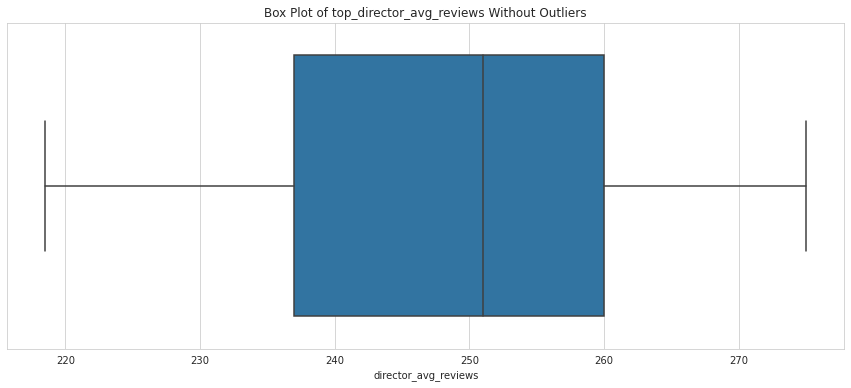

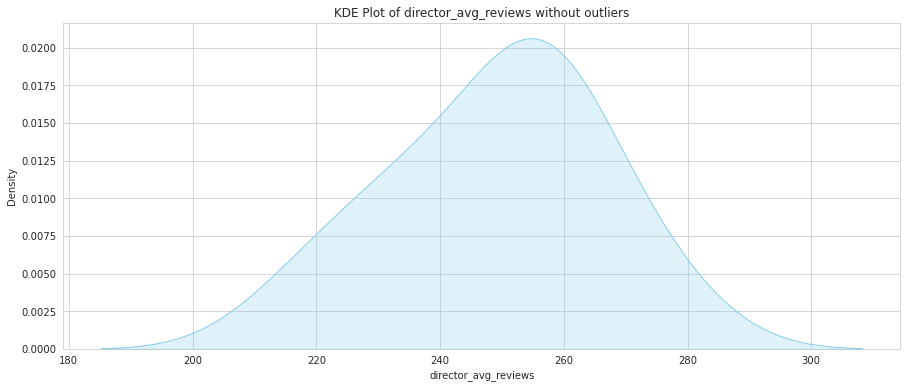

Visualizations saved to 'visuals' folder.


In [6]:
# movie_data_visualizations.py

# Importing libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Create visuals folder if it doesn't exist
os.makedirs('visuals', exist_ok=True)

# Load cleaned datasets
tmdb_tn_merged = pd.read_csv('../data/cleaned/tmdb_tn_merged_cleaned.csv')
rt_combined_df_cleaned = pd.read_csv('../data/cleaned/rt_combined_df_cleaned.csv')
top_directors_by_reviews_cleaned = pd.read_csv('../data/cleaned/top_directors_by_reviews_cleaned.csv')
top_writers_by_reviews_cleaned = pd.read_csv('../data/cleaned/top_writers_by_reviews_cleaned.csv')

# Set plotting style
sns.set_style("whitegrid")

# Production Budget vs Worldwide Gross
plt.figure(figsize=(8, 6))
sns.regplot(x='production_budget', y='worldwide_gross', data=tmdb_tn_merged,
            scatter_kws={'alpha':0.3})
plt.title('Production Budget vs Worldwide Gross')
plt.xlabel('Production Budget')
plt.ylabel('Worldwide Gross')
plt.savefig('visuals/production_budget_vs_worldwide_gross.png', bbox_inches='tight')
plt.show()

# Domestic Gross KDE
plt.figure(figsize=(15, 6))
sns.kdeplot(data=tmdb_tn_merged, x='domestic_gross', fill=True, color='skyblue')
plt.title('KDE Plot of Domestic Gross')
plt.xlabel('Domestic gross in $')
plt.ylabel('Density')
plt.savefig('visuals/domestic_gross_kde.png', bbox_inches='tight')
plt.show()

# Domestic Gross Box Plot (With Outliers)
plt.figure(figsize=(15, 6))
sns.boxplot(x=tmdb_tn_merged['domestic_gross'])
plt.title('Box Plot of dom_gross to Visualize Outliers')
plt.xlabel('dom_gross')
plt.savefig('visuals/domestic_gross_boxplot_with_outliers.png', bbox_inches='tight')
plt.show()

# Domestic Gross Box Plot (Without Outliers)
plt.figure(figsize=(15, 6))
sns.boxplot(x=tmdb_tn_merged_cleaned['domestic_gross'])
plt.title('Box Plot of Domestic Without Outliers')
plt.xlabel('Domestic_gross')
plt.savefig('visuals/domestic_gross_boxplot_without_outliers.png', bbox_inches='tight')
plt.show()

# Production Budget KDE
plt.figure(figsize=(15, 6))
sns.kdeplot(data=tmdb_tn_merged, x='production_budget', fill=True, color='skyblue')
plt.title('KDE Plot of Production_budget')
plt.xlabel('Movie Budget in $')
plt.ylabel('Density')
plt.savefig('visuals/production_budget_kde.png', bbox_inches='tight')
plt.show()

# Production Budget Box Plot (Without Outliers)
plt.figure(figsize=(15, 6))
sns.boxplot(x=tmdb_tn_merged_cleaned['production_budget'])
plt.title('Box Plot of Production Budget Without Outliers')
plt.xlabel('production_budget')
plt.savefig('visuals/production_budget_boxplot_without_outliers.png', bbox_inches='tight')
plt.show()

# Production Budget Histogram (Without Outliers)
plt.figure(figsize=(15, 6))
sns.histplot(tmdb_tn_merged_cleaned['production_budget'], kde=True)
plt.title('Distribution of production_budget without outliers')
plt.xlabel('production_budget')
plt.ylabel('Count')
plt.savefig('visuals/production_budget_histogram_without_outliers.png', bbox_inches='tight')
plt.show()

# Worldwide Gross KDE
plt.figure(figsize=(15, 6))
sns.kdeplot(data=tmdb_tn_merged, x='worldwide_gross', fill=True, color='skyblue')
plt.title('KDE Plot of Worldwide Gross')
plt.xlabel('World wide Gross in $')
plt.ylabel('Density')
plt.savefig('visuals/worldwide_gross_kde.png', bbox_inches='tight')
plt.show()

# Worldwide Gross Box Plot (Without Outliers)
plt.figure(figsize=(15, 6))
sns.boxplot(x=tmdb_tn_merged_cleaned['worldwide_gross'])
plt.title('Box Plot of worldwide_gross to Visualize Outliers')
plt.xlabel('Worldwide_gross')
plt.savefig('visuals/worldwide_gross_boxplot_without_outliers.png', bbox_inches='tight')
plt.show()

# Worldwide Gross KDE (Without Outliers)
plt.figure(figsize=(15, 6))
sns.kdeplot(data=tmdb_tn_merged_cleaned, x='worldwide_gross', fill=True, color='skyblue')
plt.title('KDE Plot of Worldwide Gross without outliers')
plt.xlabel('World wide Gross in $')
plt.ylabel('Density')
plt.savefig('visuals/worldwide_gross_kde_without_outliers.png', bbox_inches='tight')
plt.show()

# Release Year Histogram
plt.figure(figsize=(15, 6))
sns.histplot(tmdb_tn_merged['release_year'], kde=True)
plt.title('Distribution of Movie Year of Release')
plt.xlabel('release_year')
plt.ylabel('Count')
plt.savefig('visuals/release_year_histogram.png', bbox_inches='tight')
plt.show()

# Release Year Box Plot (Without Outliers)
plt.figure(figsize=(15, 6))
sns.boxplot(x=tmdb_tn_merged_cleaned['release_year'])
plt.title('Box Plot of Year of Movie Release without Outliers')
plt.xlabel('Year')
plt.savefig('visuals/release_year_boxplot_without_outliers.png', bbox_inches='tight')
plt.show()

# Release Year Histogram (Without Outliers)
plt.figure(figsize=(15, 6))
sns.histplot(tmdb_tn_merged_cleaned['release_year'], kde=True)
plt.title('Distribution of Movie Year of Release without Outliers')
plt.xlabel('release_year')
plt.ylabel('Count')
plt.savefig('visuals/release_year_histogram_without_outliers.png', bbox_inches='tight')
plt.show()

# Freshness Score KDE
plt.figure(figsize=(15, 6))
sns.kdeplot(data=rt_combined_df_cleaned, x='Freshness_score', fill=True, color='skyblue')
plt.title('KDE Plot of Freshness_score')
plt.xlabel('Freshness_score')
plt.ylabel('Density')
plt.savefig('visuals/freshness_score_kde.png', bbox_inches='tight')
plt.show()

# Review Counts Box Plot (Without Outliers)
plt.figure(figsize=(15, 6))
sns.boxplot(x=rt_combined_df_cleaned['Review_counts'])
plt.title('Box Plot of Review Counts Without Outliers')
plt.xlabel('Review Counts')
plt.savefig('visuals/review_counts_boxplot_without_outliers.png', bbox_inches='tight')
plt.show()

# Review Counts KDE
plt.figure(figsize=(15, 6))
sns.kdeplot(data=rt_combined_df_cleaned, x='Review_counts', fill=True, color='skyblue')
plt.title('KDE Plot of Number of Reviews')
plt.xlabel('Review Count')
plt.ylabel('Density')
plt.savefig('visuals/review_counts_kde.png', bbox_inches='tight')
plt.show()

# Runtime Box Plot (Without Outliers)
plt.figure(figsize=(15, 6))
sns.boxplot(x=rt_combined_df_cleaned['runtime'])
plt.title('Box Plot of Runtime Without Outliers')
plt.xlabel('Runtime in Minutes')
plt.savefig('visuals/runtime_boxplot_without_outliers.png', bbox_inches='tight')
plt.show()

# Runtime KDE
plt.figure(figsize=(15, 6))
sns.kdeplot(data=rt_combined_df_cleaned, x='runtime', fill=True, color='skyblue')
plt.title('KDE Plot of runtime in minutes')
plt.xlabel('Runtime')
plt.ylabel('Density')
plt.savefig('visuals/runtime_kde.png', bbox_inches='tight')
plt.show()

# Writer Avg Freshness Box Plot
plt.figure(figsize=(15, 6))
sns.boxplot(x=top_writers_by_reviews_cleaned['writer_avg_freshness'])
plt.title('Box Plot of top_writers_by_reviews Without Outliers')
plt.xlabel('top_writers_by_reviews')
plt.savefig('visuals/writer_avg_freshness_boxplot.png', bbox_inches='tight')
plt.show()

# Writer Avg Freshness KDE
plt.figure(figsize=(15, 6))
sns.kdeplot(data=top_writers_by_reviews_cleaned, x='writer_avg_freshness', fill=True, color='skyblue')
plt.title('KDE Plot of Writer Freshness without outliers')
plt.xlabel('Freshness')
plt.ylabel('Density')
plt.savefig('visuals/writer_avg_freshness_kde.png', bbox_inches='tight')
plt.show()

# Writer Movie Count Box Plot
plt.figure(figsize=(15, 6))
sns.boxplot(x=top_writers_by_reviews_cleaned['writer_movie_count'])
plt.title('Box Plot of top_writer movie count Without Outliers')
plt.xlabel('top_writers_by_writer_movie_count')
plt.savefig('visuals/writer_movie_count_boxplot.png', bbox_inches='tight')
plt.show()

# Writer Avg Reviews Box Plot
plt.figure(figsize=(15, 6))
sns.boxplot(x=top_writers_by_reviews_cleaned['writer_avg_reviews'])
plt.title('Box Plot of top_writer writer_avg_reviews Without Outliers')
plt.xlabel('top_writers_by_writer_avg_reviews')
plt.savefig('visuals/writer_avg_reviews_boxplot.png', bbox_inches='tight')
plt.show()

# Director Avg Freshness Box Plot
plt.figure(figsize=(15, 6))
sns.boxplot(x=top_directors_by_reviews_cleaned['director_avg_freshness'])
plt.title('Box Plot of top_director_avg_freshness Without Outliers')
plt.xlabel('director_avg_freshness')
plt.savefig('visuals/director_avg_freshness_boxplot.png', bbox_inches='tight')
plt.show()

# Director Avg Freshness KDE
plt.figure(figsize=(15, 6))
sns.kdeplot(data=top_directors_by_reviews_cleaned, x='director_avg_freshness', fill=True, color='skyblue')
plt.title('KDE Plot of Director Freshness without outliers')
plt.xlabel('Freshness')
plt.ylabel('Density')
plt.savefig('visuals/director_avg_freshness_kde.png', bbox_inches='tight')
plt.show()

# Director Avg Reviews Box Plot
plt.figure(figsize=(15, 6))
sns.boxplot(x=top_directors_by_reviews_cleaned['director_avg_reviews'])
plt.title('Box Plot of top_director_avg_reviews Without Outliers')
plt.xlabel('director_avg_reviews')
plt.savefig('visuals/director_avg_reviews_boxplot.png', bbox_inches='tight')
plt.show()

# Director Avg Reviews KDE
plt.figure(figsize=(15, 6))
sns.kdeplot(data=top_directors_by_reviews_cleaned, x='director_avg_reviews', fill=True, color='skyblue')
plt.title('KDE Plot of director_avg_reviews without outliers')
plt.xlabel('director_avg_reviews')
plt.ylabel('Density')
plt.savefig('visuals/director_avg_reviews_kde.png', bbox_inches='tight')
plt.show()

print("Visualizations saved to 'visuals' folder.")